# IESTI01 Projeto Final

## Montando Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import h5py
import tensorflow as tf
import numpy as np
from tensorflow import keras
from keras.applications import MobileNet
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, GlobalAveragePooling2D, TimeDistributed, LSTM, Dense
from keras.models import Model
from tensorflow.keras.utils import Sequence
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
import h5py
import numpy as np
from numpy.lib.format import open_memmap

file_path = '/content/drive/MyDrive/Faculdade/IESTI01/faceImages_small.h5'

batch_size = 512

n_train01 = 6801
n_val = 1360
n_test = 1360

with h5py.File(file_path, 'r') as f:
    x_train = f['x_train']
    y_train = f['y_train']
    total_samples = x_train.shape[0]
    x_shape = x_train.shape[1:]
    y_shape = y_train.shape[1:]

    x_train01_np = open_memmap('x_train01.npy', mode='w+', dtype=x_train.dtype, shape=(n_train01, *x_shape))
    y_train01_np = open_memmap('y_train01.npy', mode='w+', dtype=y_train.dtype, shape=(n_train01, *y_shape))
    x_val_np     = open_memmap('x_val.npy',     mode='w+', dtype=x_train.dtype, shape=(n_val,     *x_shape))
    y_val_np     = open_memmap('y_val.npy',     mode='w+', dtype=y_train.dtype, shape=(n_val,     *y_shape))
    x_test_np    = open_memmap('x_test.npy',    mode='w+', dtype=x_train.dtype, shape=(n_test,    *x_shape))
    y_test_np    = open_memmap('y_test.npy',    mode='w+', dtype=y_train.dtype, shape=(n_test,    *y_shape))

    def copy_to_memmap(x_out, y_out, n_samples, name, random_state):
        print(f"Copiando {name}...")
        samples_batches = n_samples // batch_size
        total_batches = total_samples // batch_size

        rng = np.random.default_rng(seed=random_state)
        batches = rng.integers(low=0, high=total_batches, size=samples_batches)

        for i, batch in enumerate(batches):
            start = batch * batch_size
            end = start + batch_size
            out_start = i * batch_size
            out_end = out_start + batch_size
            x_out[out_start:out_end] = x_train[start:end]
            y_out[out_start:out_end] = y_train[start:end]

        restante = n_samples % batch_size
        if restante > 0:
            batch = np.random.randint(0, total_batches)
            start = batch * batch_size
            x_out[-restante:] = x_train[start:start + restante]
            y_out[-restante:] = y_train[start:start + restante]

    # Copiando os dados
    copy_to_memmap(x_train01_np, y_train01_np, n_train01, 'train01', random_state=42)
    copy_to_memmap(x_val_np, y_val_np, n_val, 'val', random_state=43)
    copy_to_memmap(x_test_np, y_test_np, n_test, 'test', random_state=45)

print("Arquivo reorganizado com sucesso ✅")

Copiando train01...
Copiando val...
Copiando test...
Arquivo reorganizado com sucesso ✅


In [ ]:
x_train = np.load('x_train01.npy', mmap_mode='r')
y_train = np.load('y_train01.npy', mmap_mode='r')

x_train.shape, y_train.shape

((13602, 38, 96, 96, 3), (13602,))

In [ ]:
valores, contagens = np.unique(y_train, return_counts=True)
valores, contagens

(array([0, 1], dtype=uint8), array([5249, 8353]))

In [ ]:
x_val = np.load('x_val.npy', mmap_mode='r')
y_val = np.load('y_val.npy', mmap_mode='r')

valores, contagens = np.unique(y_val, return_counts=True)
valores, contagens

(array([0, 1], dtype=uint8), array([1282, 1438]))

In [ ]:
x_test = np.load('x_test.npy', mmap_mode='r')
y_test = np.load('y_test.npy', mmap_mode='r')

valores, contagens = np.unique(y_test, return_counts=True)
valores, contagens

(array([1], dtype=uint8), array([2720]))

## Importando Dataset

In [ ]:
class DataLoader(Sequence):
    def __init__(self, dataset, batch_size, **kwargs):
        super().__init__(**kwargs)
        self.batch_size = batch_size
        if dataset == 'train':
          self.x_data = np.load('x_train01.npy', mmap_mode='r')
          self.y_data = np.load('y_train01.npy', mmap_mode='r')
        elif dataset == 'val':
          self.x_data = np.load('x_val.npy', mmap_mode='r')
          self.y_data = np.load('y_val.npy', mmap_mode='r')
        elif dataset == 'test':
          self.x_data = np.load('x_test.npy', mmap_mode='r')
          self.y_data = np.load('y_test.npy', mmap_mode='r')

    def __len__(self):
        return int(np.ceil(len(self.x_data) / self.batch_size))

    def __getitem__(self, idx):
        start = idx * self.batch_size
        end = start + self.batch_size
        return self.x_data[start:end] / 255.0, self.y_data[start:end]

train_loader = DataLoader('train', batch_size=32)
val_loader = DataLoader('val', batch_size=32)
test_loader = DataLoader('test', batch_size=32)

## Definindo modelo

In [ ]:
# Configurações
timesteps = 38
height, width, channels = 96, 96, 3

# Entrada: sequência de imagens
input_layer = Input(shape=(timesteps, height, width, channels))

# Backbone CNN com TimeDistributed
base_cnn = MobileNet(weights='imagenet', include_top=False, input_shape=(height, width, channels))
base_cnn.trainable = False  # opcional: para fine-tuning posterior

x = TimeDistributed(base_cnn)(input_layer)
x = TimeDistributed(GlobalAveragePooling2D())(x)  # reduz dimensão espacial

# LSTM para modelar a sequência temporal
x = LSTM(32)(x)

# Camadas densas
x = Dense(512, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)  # binário: falando ou não

model = Model(inputs=input_layer, outputs=output)
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

/tmp/ipython-input-24-289702444.py:9: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_cnn = MobileNet(weights='imagenet', include_top=False, input_shape=(height, width, channels))


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 38, 96, 96, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 38, 3, 3, 1024) │     3,228,864 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 38, 1024)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │       135,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,381,569 (12.90 MB)

 Trainable params: 152,705 (596.50 KB)

 Non-trainable params: 3,228,864 (12.32 MB)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',     # métrica a ser monitorada
    patience=3,             # quantas épocas esperar antes de parar
    restore_best_weights=True  # volta para os melhores pesos observados
)

In [ ]:
model.fit(train_loader, validation_data=val_loader, epochs=10, callbacks=[early_stop])

Epoch 1/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 316s 965ms/step - accuracy: 0.5526 - loss: 0.6867 - val_accuracy: 0.5007 - val_loss: 0.6938
Epoch 2/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 175s 819ms/step - accuracy: 0.5614 - loss: 0.6887 - val_accuracy: 0.6243 - val_loss: 0.6699
Epoch 3/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 174s 816ms/step - accuracy: 0.5374 - loss: 0.6933 - val_accuracy: 0.6243 - val_loss: 0.6580
Epoch 4/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 172s 809ms/step - accuracy: 0.5645 - loss: 0.6845 - val_accuracy: 0.6294 - val_loss: 0.6591
Epoch 5/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 211s 850ms/step - accuracy: 0.6130 - loss: 0.6638 - val_accuracy: 0.5338 - val_loss: 0.6860
Epoch 6/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 190s 796ms/step - accuracy: 0.5633 - loss: 0.6843 - val_accuracy: 0.5993 - val_loss: 0.6740


## Modelo menor para TinyML

In [ ]:
class TinyLoader(Sequence):
    def __init__(self, dataset, batch_size, **kwargs):
        super().__init__(**kwargs)
        self.batch_size = batch_size
        if dataset == 'train':
          self.x_data = np.load('x_train01.npy', mmap_mode='r')
          self.y_data = np.load('y_train01.npy', mmap_mode='r')
        elif dataset == 'val':
          self.x_data = np.load('x_val.npy', mmap_mode='r')
          self.y_data = np.load('y_val.npy', mmap_mode='r')
        elif dataset == 'test':
          self.x_data = np.load('x_test.npy', mmap_mode='r')
          self.y_data = np.load('y_test.npy', mmap_mode='r')

    def __len__(self):
        return int(np.ceil(len(self.x_data) / self.batch_size))

    def _generate_sliding_windows(self, clip):
      # clip: (38, 96, 96, 1)
      sequences = []
      for i in range(5):
          seq = []
          for j in range(7):
              seq.append(clip[j + 7 * i])
          sequences.append(seq)
      return np.array(sequences)

    def __getitem__(self, idx):
        start = idx * self.batch_size
        end = start + self.batch_size

        x_samples = []
        y_samples = []

        for clip, label in zip(self.x_data[start:end], self.y_data[start:end]):
            # Convert to grayscale: 0.2989*R + 0.5870*G + 0.1140*B
            gray_clip = np.dot(clip[...,:3], [0.2989, 0.5870, 0.1140])  # shape: (5, H, W)
            gray_clip = np.expand_dims(gray_clip, -1)  # shape: (5, H, W, 1)

            for sequence in self._generate_sliding_windows(gray_clip):
              x_samples.append(sequence / 255.0)
              y_samples.append(label)
        return np.array(x_samples), np.array(y_samples)


train_loader = TinyLoader('train', batch_size=32)
val_loader = TinyLoader('val', batch_size=32)
test_loader = TinyLoader('test', batch_size=32)

In [ ]:
timesteps = 7
height, width, channels = 96, 96, 1
input_shape = (timesteps, height, width, channels)

def tiny_cnn():
    model = Sequential([
        Conv2D(4, (3, 3), activation='relu', padding='same'),
        MaxPooling2D(2, 2),
        Conv2D(8, (3, 3), activation='relu', padding='same'),
        MaxPooling2D(2, 2),
        Conv2D(16, (3, 3), activation='relu', padding='same'),
        GlobalAveragePooling2D(),
    ])
    return model

# Entrada
input_layer = Input(shape=input_shape)

# CNN + TimeDistributed
cnn = tiny_cnn()
x = TimeDistributed(cnn)(input_layer)

# LSTM compatível com TFLite
x = LSTM(8, activation='tanh', recurrent_activation='sigmoid', unroll=True)(x)

# Camadas finais
x = Dense(16, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)  # binário: falando ou não

# Modelo final
model = Model(inputs=input_layer, outputs=output)

# Compilação
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Resumo
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 7, 96, 96, 1)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 7, 16)          │         1,504 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 8)              │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,465 (9.63 KB)

 Trainable params: 2,465 (9.63 KB)

 Non-trainable params: 0 (0.00 B)

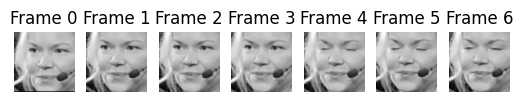

In [ ]:
import matplotlib.pyplot as plt

for clip in train_loader:
    x_batch = clip[0]
    for j in range(7):
      img = x_batch[0, j, :, :, 0]
      plt.subplot(1, 7, j+1)
      plt.imshow(img, cmap='gray')
      plt.axis('off')
      plt.title(f'Frame {j}')
    break

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',     # métrica a ser monitorada
    patience=3,             # quantas épocas esperar antes de parar
    restore_best_weights=True  # volta para os melhores pesos observados
)

In [ ]:
model.fit(train_loader, validation_data=val_loader, epochs=10, callbacks=[early_stop])

Epoch 1/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 155s 690ms/step - accuracy: 0.4431 - loss: 0.6963 - val_accuracy: 0.6235 - val_loss: 0.6877
Epoch 2/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 141s 662ms/step - accuracy: 0.5233 - loss: 0.6935 - val_accuracy: 0.6235 - val_loss: 0.6848
Epoch 3/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 126s 590ms/step - accuracy: 0.5846 - loss: 0.6875 - val_accuracy: 0.6235 - val_loss: 0.6852
Epoch 4/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 118s 556ms/step - accuracy: 0.5195 - loss: 0.6936 - val_accuracy: 0.6235 - val_loss: 0.6833
Epoch 5/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 114s 536ms/step - accuracy: 0.5325 - loss: 0.6924 - val_accuracy: 0.6235 - val_loss: 0.6832
Epoch 6/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 147s 689ms/step - accuracy: 0.5270 - loss: 0.6928 - val_accuracy: 0.6235 - val_loss: 0.6826
Epoch 7/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 138s 646ms/step - accuracy: 0.5672 - loss: 0.6887 - val_accuracy: 0.6235 - val_loss: 0.6829
Epoch 8/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 138s 648ms/step - accuracy: 0.5394 -

## Transformando para TFLite

In [ ]:
from tensorflow.keras.models import load_model

model = load_model('/content/drive/MyDrive/Faculdade/IESTI01/projetofinaliIESTI01.keras')

In [ ]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 7, 96, 96, 1)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 7, 16)          │         1,504 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 8)              │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,467 (9.64 KB)

 Trainable params: 2,465 (9.63 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [ ]:
cnn_model = cnn
cnn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 96, 96, 4)      │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 48, 48, 4)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 48, 48, 8)      │           296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 24, 24, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 24, 24, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 16)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,504 (5.88 KB)

 Trainable params: 1,504 (5.88 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cnn_weights = model.get_layer(index=1).get_weights()
cnn_model.set_weights(cnn_weights)

In [ ]:
embedding_dim = cnn_model.output_shape[-1]  # deve ser 32 no seu caso
lstm_input = Input(shape=(timesteps, embedding_dim))

# Recria parte LSTM do modelo original
x = LSTM(8, activation='tanh', recurrent_activation='sigmoid', unroll=True)(lstm_input)
x = Dense(16, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)

lstm_model = Model(inputs=lstm_input, outputs=output)
lstm_model.summary()

Model: "functional_27"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 7, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 8)              │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 961 (3.75 KB)

 Trainable params: 961 (3.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
lstm_weights = model.get_layer("lstm").get_weights()
lstm_model.get_layer("lstm_6").set_weights(lstm_weights)

dense_4_weights = model.get_layer("dense").get_weights()
lstm_model.get_layer("dense_12").set_weights(dense_4_weights)

dense_5_weights = model.get_layer("dense_1").get_weights()
lstm_model.get_layer("dense_13").set_weights(dense_5_weights)

In [ ]:
def representative_data_gen():
    for _ in range(100):
        yield [np.random.rand(1, 96, 96, 1).astype(np.float32)]

cnn_converter = tf.lite.TFLiteConverter.from_keras_model(cnn_model)
cnn_converter.optimizations = [tf.lite.Optimize.DEFAULT]
cnn_converter.representative_dataset = representative_data_gen
cnn_converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
cnn_converter.inference_input_type = tf.int8
cnn_converter.inference_output_type = tf.int8

cnn_tflite = cnn_converter.convert()

with open("cnn_model.tflite", "wb") as f:
    f.write(cnn_tflite)

Saved artifact at '/tmp/tmpunxzg5bi'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 96, 96, 1), dtype=tf.float32, name='keras_tensor_99')
Output Type:
  TensorSpec(shape=(None, 16), dtype=tf.float32, name=None)
Captures:
  134328145097360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134328145085840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134328145097936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134328145094864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134328145099472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134328053947408: TensorSpec(shape=(), dtype=tf.resource, name=None)


/usr/local/lib/python3.11/dist-packages/tensorflow/lite/python/convert.py:997: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


In [ ]:
def representative_data_gen():
    for _ in range(100):
        yield [np.random.rand(1, 7, 16).astype(np.float32)]

lstm_converter = tf.lite.TFLiteConverter.from_keras_model(lstm_model)
lstm_converter.optimizations = [tf.lite.Optimize.DEFAULT]
lstm_converter.representative_dataset = representative_data_gen
lstm_converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
lstm_converter.inference_input_type = tf.int8
lstm_converter.inference_output_type = tf.int8

lstm_tflite = lstm_converter.convert()

# Salvar arquivo .tflite quantizado
with open("lstm_model.tflite", "wb") as f:
    f.write(lstm_tflite)

Saved artifact at '/tmp/tmp7q97b6gj'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 7, 16), dtype=tf.float32, name='keras_tensor_147')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  134328047537616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134328047542032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134328047542608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134328047540688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134328047542224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134328047541456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134328047543568: TensorSpec(shape=(), dtype=tf.resource, name=None)


/usr/local/lib/python3.11/dist-packages/tensorflow/lite/python/convert.py:997: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


In [ ]:
!xxd -i cnn_model.tflite > cnn_model.cc
!xxd -i lstm_model.tflite > lstm_model.cc